# Task 1: Exploratory Analysis of Environmental Microbiome Dataset

**Objective:** Characterize the overall structure, quality, and heterogeneity of the dataset to understand its suitability for downstream microbiome analyses.

---

## Setup and Data Loading

In [9]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries loaded successfully")

Libraries loaded successfully


In [ ]:
# File paths
INPUT_DIR = 'input'
OUTPUT_DIR = 'output'

OUTPUT_PATH = f'{OUTPUT_DIR}/exploratory_analysis'
META_FILE_NAME = 'environmental_core_wide_2026-02-01.tsv'
SPECIES_FILE_NAME = 'environmental_metaphlan4_species_2026-02-01.tsv'

folder_path = Path(f'{OUTPUT_PATH}')
folder_path.mkdir(parents=True, exist_ok=True)
print(f"Folder '{OUTPUT_PATH}' is ready.")

# Load metadata
print("Loading metadata...")
metadata_df = pd.read_csv(f'{INPUT_DIR}/{META_FILE_NAME}', sep='\t')
print(f"Metadata loaded: {metadata_df.shape[0]} samples × {metadata_df.shape[1]} variables")

# Load species abundance data
print("\nLoading species abundance data...")
species_long = pd.read_csv(f'{INPUT_DIR}/{SPECIES_FILE_NAME}', sep='\t')
print(f"Species data loaded: {len(species_long)} rows (long format)")

# Display first rows
print("\n=== Metadata Preview ===")
display(metadata_df.head())

print("\n=== Species Abundance Preview ===")
display(species_long.head())

Folder 'output/exploratory_analysis' is ready.
Loading metadata...
Metadata loaded: 26938 samples × 27 variables

Loading species abundance data...
Species data loaded: 1659836 rows (long format)

=== Metadata Preview ===


,study_code,sample_alias,spire_sample_name,longitude,latitude,geographic_location,location_resolution,collection_date,collection_date_end,last_change,...,depth_meters,pH,temperature,mean_annual_precipitation_mm,mean_annual_temperature,pmid,doi,location,filtration_lower_threshold_um,filtration_upper_threshold_um
0,Zhang_2023_wastewater,Zhang_2023_wastewater.CAP-120c-0h-ont,SAMN34121631,114.12,22.42,China,city,2020-01-01,2020-12-31,2025-09-19 16:25:16.862777,...,NaN,NaN,NaN,NaN,NaN,NaN,10.1016/j.eng.2023.07.009,China: Shenzhen,NaN,NaN
1,Zhang_2023_wastewater,Zhang_2023_wastewater.CAP-120c-18h-ont,SAMN34121632,114.12,22.42,China,city,2020-01-01,2020-12-31,2025-09-19 16:25:16.862777,...,NaN,NaN,NaN,NaN,NaN,NaN,10.1016/j.eng.2023.07.009,China: Shenzhen,NaN,NaN
2,Zhang_2023_wastewater,Zhang_2023_wastewater.CAP-120c-28h-ont,SAMN34121633,114.12,22.42,China,city,2020-01-01,2020-12-31,2025-09-19 16:25:16.862777,...,NaN,NaN,NaN,NaN,NaN,NaN,10.1016/j.eng.2023.07.009,China: Shenzhen,NaN,NaN
3,Zhang_2023_wastewater,Zhang_2023_wastewater.CAP-120c-48h-ont,SAMN34121634,114.12,22.42,China,city,2020-01-01,2020-12-31,2025-09-19 16:25:16.862777,...,NaN,NaN,NaN,NaN,NaN,NaN,10.1016/j.eng.2023.07.009,China: Shenzhen,NaN,NaN
4,Zhang_2023_wastewater,Zhang_2023_wastewater.PNB-100-0h-ont,SAMN34121635,114.12,22.42,China,city,2020-01-01,2020-12-31,2025-09-19 16:25:16.862777,...,NaN,NaN,NaN,NaN,NaN,NaN,10.1016/j.eng.2023.07.009,China: Shenzhen,NaN,NaN



=== Species Abundance Preview ===


,sample_alias,species,rel_abund
0,Tremblay_2017_marine.sample_control_Hibernia_S...,s__GGB68842_SGB92854,0.00069
1,Tremblay_2017_marine.sample_control_Hibernia_S...,s__GGB47326_SGB91780,0.00301
2,Tremblay_2017_marine.sample_control_Hibernia_S...,s__GGB26984_SGB91374,0.00389
3,Tremblay_2017_marine.sample_control_Hibernia_S...,s__GGB46753_SGB64636,0.00502
4,Tremblay_2017_marine.sample_control_Hibernia_S...,s__GGB45723_SGB92446,0.00608


---
## 1. Dataset Size and Structure

In [12]:
total_samples_meta = len(metadata_df)
unique_samples_species = species_long['sample_alias'].nunique()

print("="*80)
print("DATASET SIZE")
print("="*80)
print(f"\nTotal samples in metadata: {total_samples_meta:,}")
print(f"Unique samples in species data: {unique_samples_species:,}")

# Check for sample overlap
meta_samples = set(metadata_df['sample_alias'])
species_samples = set(species_long['sample_alias'])

common_samples = meta_samples.intersection(species_samples)
only_meta = meta_samples - species_samples
only_species = species_samples - meta_samples

print(f"\nSamples in both files: {len(common_samples):,}")
print(f"Samples only in metadata: {len(only_meta):,}")
print(f"Samples only in species data: {len(only_species):,}")

if len(only_meta) > 0:
    print(f"\n⚠️ {len(only_meta)} samples in metadata have no species data")
if len(only_species) > 0:
    print(f"⚠️ {len(only_species)} samples in species data have no metadata")

DATASET SIZE

Total samples in metadata: 26,938
Unique samples in species data: 16,994

Samples in both files: 16,994
Samples only in metadata: 9,944
Samples only in species data: 0

⚠️ 9944 samples in metadata have no species data


---
## 2. Study Distribution

In [13]:
n_studies = metadata_df['study_code'].nunique()

print("="*80)
print("STUDY DISTRIBUTION")
print("="*80)
print(f"\nNumber of independent studies: {n_studies}")

# Q3: What are the min, max, and mean numbers of samples per study?
samples_per_study = metadata_df.groupby('study_code').size()

print(f"\nSamples per study statistics:")
print(f"  Minimum: {samples_per_study.min()}")
print(f"  Maximum: {samples_per_study.max()}")
print(f"  Mean: {samples_per_study.mean():.1f}")
print(f"  Median: {samples_per_study.median():.0f}")
print(f"  Std Dev: {samples_per_study.std():.1f}")

# Show top 10 studies by sample count
print(f"\nTop 10 studies by sample count:")
top_studies = samples_per_study.sort_values(ascending=False).head(10)
for study, count in top_studies.items():
    pct = count / total_samples_meta * 100
    print(f"  {study}: {count} samples ({pct:.1f}%)")

STUDY DISTRIBUTION

Number of independent studies: 391

Samples per study statistics:
  Minimum: 1
  Maximum: 1579
  Mean: 68.9
  Median: 30
  Std Dev: 131.8

Top 10 studies by sample count:
  JGI_darkmatter: 1579 samples (5.9%)
  Lee_2024_house_dust: 879 samples (3.3%)
  Gusareva_2019_air: 783 samples (2.9%)
  Panwar_2020_lake_Antarctica: 654 samples (2.4%)
  Probst_2018_aquifer: 625 samples (2.3%)
  Shaffer_2021_EMP500: 586 samples (2.2%)
  Wang_2021_Arctic: 543 samples (2.0%)
  Bahram_2018_soil: 479 samples (1.8%)
  JGI_soil_forest_LTER: 435 samples (1.6%)
  Ohara_2017_ambulance: 398 samples (1.5%)


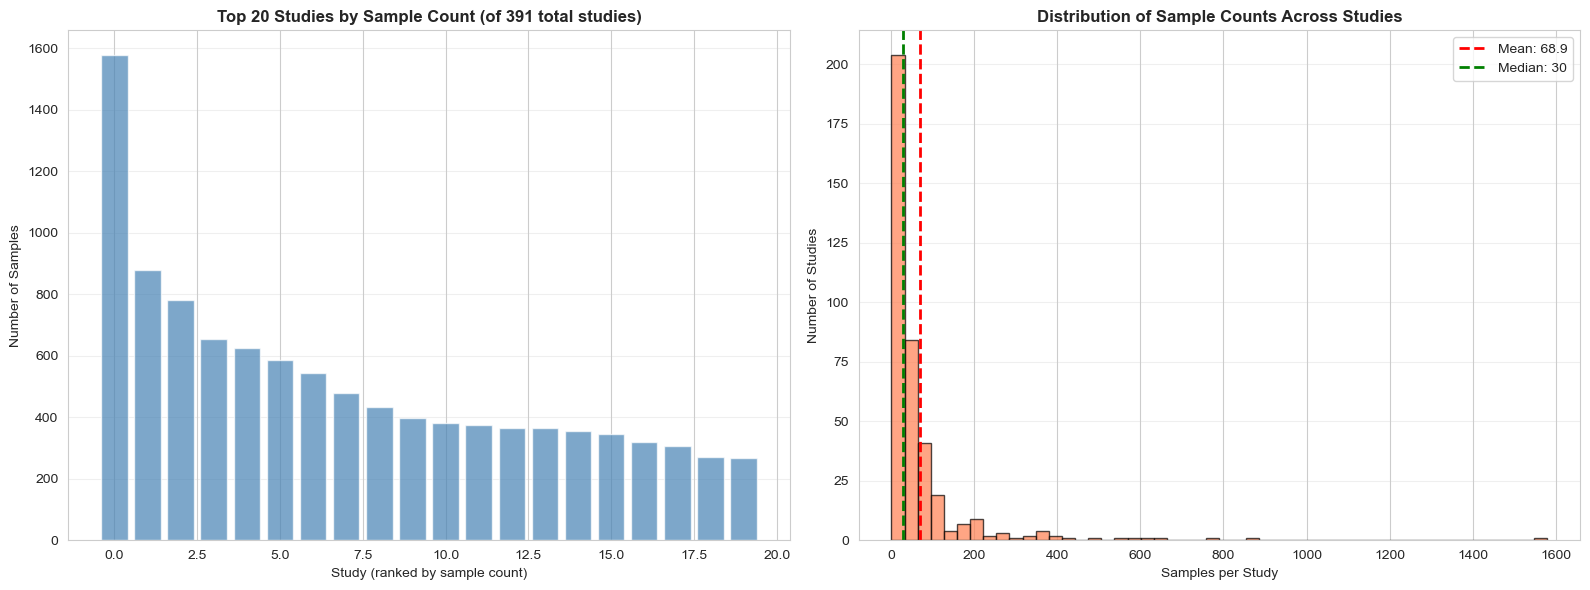

✓ Figure saved: output/study_distribution.png


In [14]:
# Samples per study
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot of top 20 studies
ax1 = axes[0]
top_20 = samples_per_study.sort_values(ascending=False).head(20)
ax1.bar(range(len(top_20)), top_20.values, color='steelblue', alpha=0.7)
ax1.set_xlabel('Study (ranked by sample count)')
ax1.set_ylabel('Number of Samples')
ax1.set_title(f'Top 20 Studies by Sample Count (of {n_studies} total studies)', 
              fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Histogram of sample counts
ax2 = axes[1]
ax2.hist(samples_per_study, bins=50, color='coral', alpha=0.7, edgecolor='black')
ax2.axvline(samples_per_study.mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {samples_per_study.mean():.1f}')
ax2.axvline(samples_per_study.median(), color='green', linestyle='--', 
            linewidth=2, label=f'Median: {samples_per_study.median():.0f}')
ax2.set_xlabel('Samples per Study')
ax2.set_ylabel('Number of Studies')
ax2.set_title('Distribution of Sample Counts Across Studies', fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/study_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved: '{OUTPUT_PATH}/study_distribution.png'")

---
## 3. Metadata Field Analysis

In [18]:
print("="*80)
print("METADATA FIELDS INVENTORY")
print("="*80)

# Categorize metadata fields
field_categories = {
    'Identifiers': [],
    'Geographic': [],
    'Temporal': [],
    'Environmental': [],
    'Technical': [],
    'Physicochemical': [],
    'Administrative': [],
    'Other': []
}

# Classify fields (based on common environmental metadata)
identifier_keywords = ['sample', 'study', 'id', 'name', 'code', 'alias']
geographic_keywords = ['location', 'longitude', 'latitude', 'geographic', 'country', 'region']
temporal_keywords = ['date', 'time', 'year', 'season', 'collection']
environmental_keywords = ['biome', 'environment', 'habitat', 'material', 'feature', 'package']
technical_keywords = ['filtration', 'sequencing', 'platform', 'method', 'library']
physicochemical_keywords = ['ph', 'temperature', 'elevation', 'depth', 'salinity', 'precipitation']
administrative_keywords = ['pmid', 'doi', 'change', 'tax_id']

for col in metadata_df.columns:
    col_lower = col.lower()
    
    if any(kw in col_lower for kw in identifier_keywords):
        field_categories['Identifiers'].append(col)
    elif any(kw in col_lower for kw in geographic_keywords):
        field_categories['Geographic'].append(col)
    elif any(kw in col_lower for kw in temporal_keywords):
        field_categories['Temporal'].append(col)
    elif any(kw in col_lower for kw in environmental_keywords):
        field_categories['Environmental'].append(col)
    elif any(kw in col_lower for kw in technical_keywords):
        field_categories['Technical'].append(col)
    elif any(kw in col_lower for kw in physicochemical_keywords):
        field_categories['Physicochemical'].append(col)
    elif any(kw in col_lower for kw in administrative_keywords):
        field_categories['Administrative'].append(col)
    else:
        field_categories['Other'].append(col)

# Display categorized fields
for category, fields in field_categories.items():
    if len(fields) > 0:
        print(f"\n{category} ({len(fields)} fields):")
        for field in fields:
            print(f"  - {field}")

METADATA FIELDS INVENTORY

Identifiers (5 fields):
  - study_code
  - sample_alias
  - spire_sample_name
  - tax_id
  - pmid

Geographic (5 fields):
  - longitude
  - latitude
  - geographic_location
  - location_resolution
  - location

Temporal (2 fields):
  - collection_date
  - collection_date_end

Environmental (4 fields):
  - environment_material
  - environment_biome
  - environmental_package
  - environment_feature

Technical (2 fields):
  - filtration_lower_threshold_um
  - filtration_upper_threshold_um

Physicochemical (6 fields):
  - elevation_meters
  - depth_meters
  - pH
  - temperature
  - mean_annual_precipitation_mm
  - mean_annual_temperature

Administrative (2 fields):
  - last_change
  - doi

Other (1 fields):
  - artificial


---
## 4. Missing Data Analysis

In [23]:
print("="*80)
print("MISSING DATA ANALYSIS")
print("="*80)

# Calculate missing data
missing_counts = metadata_df.isnull().sum()
missing_pct = (missing_counts / len(metadata_df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Field': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Missing_Percent': missing_pct.values,
    'Available_Count': len(metadata_df) - missing_counts.values
})

# Sort by missing percentage
missing_summary = missing_summary.sort_values('Missing_Percent', ascending=False)

print(f"\nMissing data summary:")
print(f"  Fields with no missing data: {(missing_summary['Missing_Percent'] == 0).sum()}")
print(f"  Fields with <10% missing: {(missing_summary['Missing_Percent'] < 10).sum()}")
print(f"  Fields with 10-50% missing: {((missing_summary['Missing_Percent'] >= 10) & (missing_summary['Missing_Percent'] < 50)).sum()}")
print(f"  Fields with 50-90% missing: {((missing_summary['Missing_Percent'] >= 50) & (missing_summary['Missing_Percent'] < 90)).sum()}")
print(f"  Fields with >90% missing: {(missing_summary['Missing_Percent'] >= 90).sum()}")

print(f"\n\nFields with >50% missing data:")
high_missing = missing_summary[missing_summary['Missing_Percent'] > 50]
if len(high_missing) > 0:
    display(high_missing)
else:
    print("  None")

# Save full missing data report
missing_summary.to_csv(f'{OUTPUT_PATH}/missing_data_summary.csv', index=False)
print(f"\nFull missing data report saved: {OUTPUT_PATH}/missing_data_summary.csv")

MISSING DATA ANALYSIS

Missing data summary:
  Fields with no missing data: 11
  Fields with <10% missing: 15
  Fields with 10-50% missing: 2
  Fields with 50-90% missing: 6
  Fields with >90% missing: 4


Fields with >50% missing data:


,Field,Missing_Count,Missing_Percent,Available_Count
20,mean_annual_precipitation_mm,25684,95.34,1254
21,mean_annual_temperature,25677,95.32,1261
26,filtration_upper_threshold_um,24624,91.41,2314
25,filtration_lower_threshold_um,24589,91.28,2349
19,temperature,23155,85.96,3783
18,pH,22642,84.05,4296
15,artificial,22035,81.80,4903
8,collection_date_end,21290,79.03,5648
16,elevation_meters,18809,69.82,8129
17,depth_meters,15088,56.01,11850



Full missing data report saved: output/exploratory_analysis/missing_data_summary.csv


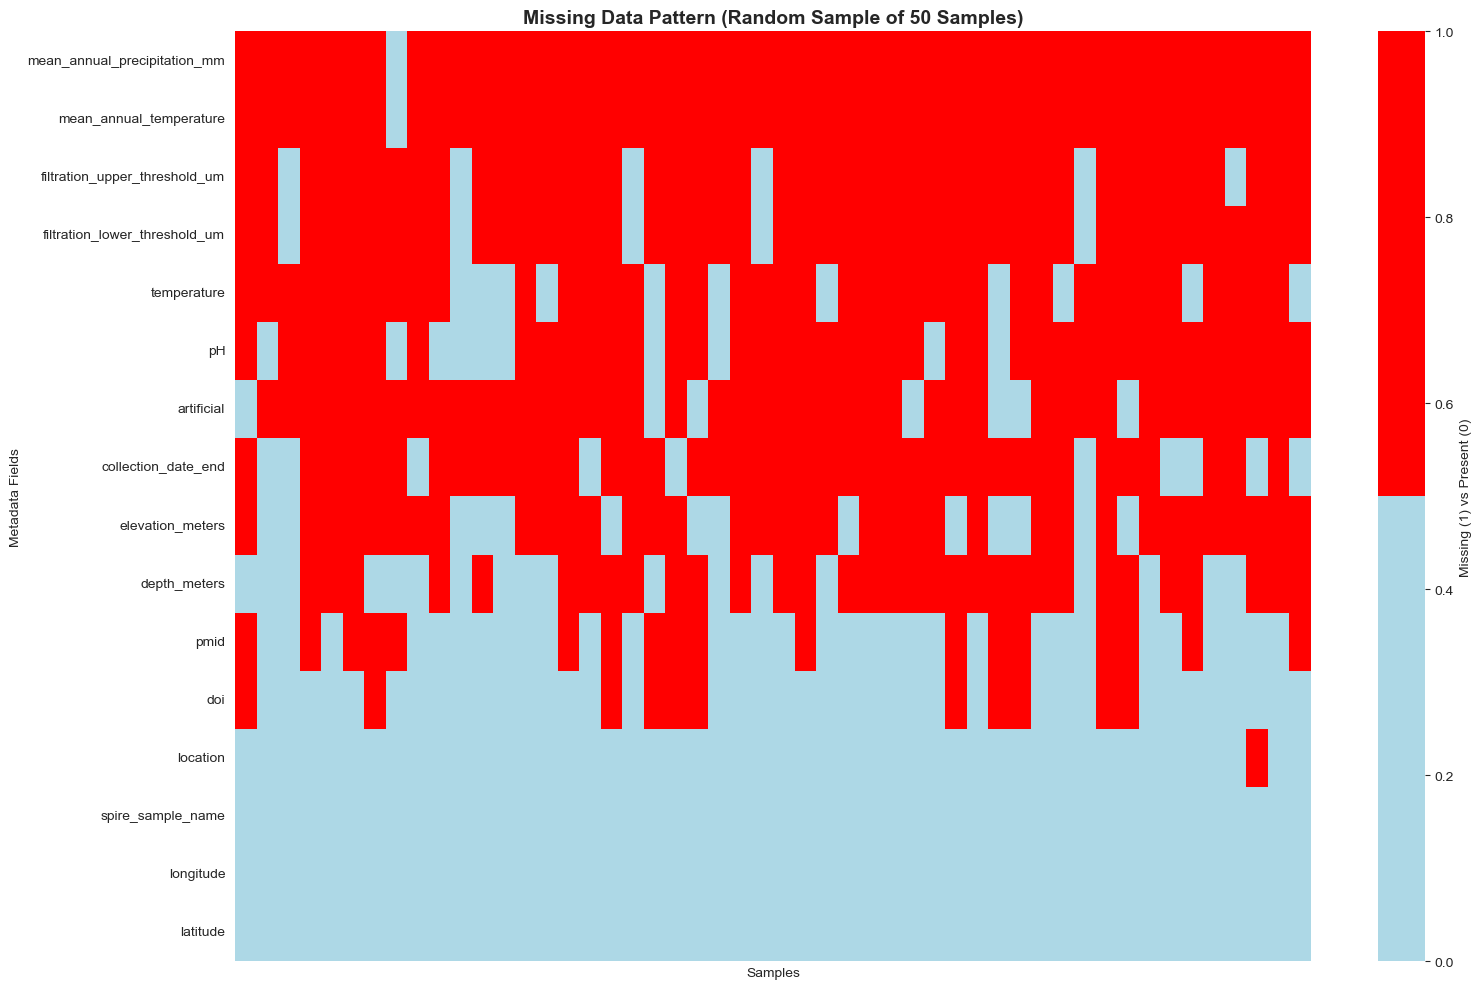

Figure saved: output/exploratory_analysis/missing_data_heatmap.png


In [24]:
# Visualization: Missing data heatmap
# Sample 50 random samples for visualization (if dataset is large)
if len(metadata_df) > 50:
    viz_samples = metadata_df.sample(n=min(50, len(metadata_df)), random_state=42)
else:
    viz_samples = metadata_df

# Create missing data matrix
missing_matrix = viz_samples.isnull().astype(int)

# Only show fields with some missing data
fields_with_missing = missing_summary[missing_summary['Missing_Percent'] > 0]['Field'].values
if len(fields_with_missing) > 0:
    missing_matrix_subset = missing_matrix[fields_with_missing]
    
    plt.figure(figsize=(16, 10))
    sns.heatmap(missing_matrix_subset.T, cmap=['lightblue', 'red'], 
                cbar_kws={'label': 'Missing (1) vs Present (0)'},
                yticklabels=True, xticklabels=False)
    plt.title(f'Missing Data Pattern (Random Sample of {len(viz_samples)} Samples)', 
              fontweight='bold', fontsize=14)
    plt.xlabel('Samples')
    plt.ylabel('Metadata Fields')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_PATH}/missing_data_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Figure saved: {OUTPUT_PATH}/missing_data_heatmap.png")
else:
    print("No missing data detected - heatmap not needed")

---
## 5. Missing Data Patterns by Study

In [25]:
print("="*80)
print("MISSING DATA PATTERNS BY STUDY")
print("="*80)

# Calculate missing percentage by study for key fields
key_fields = ['pH', 'temperature', 'elevation_meters', 'depth_meters', 
              'mean_annual_precipitation_mm', 'mean_annual_temperature']

# Only analyze fields that exist
existing_key_fields = [f for f in key_fields if f in metadata_df.columns]

if len(existing_key_fields) > 0:
    missing_by_study = metadata_df.groupby('study_code')[existing_key_fields].apply(
        lambda x: (x.isnull().sum() / len(x) * 100).round(1)
    )
    
    print(f"\nMissing data percentage for physicochemical variables by study:")
    print(f"(Showing studies with >50% missing for at least one variable)\n")
    
    # Find studies with high missing data
    high_missing_studies = missing_by_study[(missing_by_study > 50).any(axis=1)]
    
    if len(high_missing_studies) > 0:
        display(high_missing_studies.head(20))
        print(f"\n⚠️  {len(high_missing_studies)} studies have >50% missing for at least one key variable")
    else:
        print("No studies with >50% missing data for key variables")
else:
    print("⚠️  No physicochemical fields found in metadata")

MISSING DATA PATTERNS BY STUDY

Missing data percentage for physicochemical variables by study:
(Showing studies with >50% missing for at least one variable)



,pH,temperature,elevation_meters,depth_meters,mean_annual_precipitation_mm,mean_annual_temperature
study_code,,,,,,
Achberger_2024_hydrothermal_vent,100.0,100.0,0.0,0.0,100.0,100.0
AguirreVonWobeser_2021_avocado,100.0,100.0,100.0,55.6,100.0,100.0
AlAshhab_2022_freshwater,8.8,1.8,100.0,0.0,100.0,100.0
Alneberg_2018_marine_baltic,90.9,0.0,100.0,0.0,100.0,100.0
An_2013_hydrocarbon,100.0,100.0,100.0,76.0,100.0,100.0
Andren_2015_sediment_Baltic_Sea,100.0,100.0,100.0,0.0,100.0,100.0
Angle_2017_wetland,100.0,100.0,100.0,57.1,100.0,100.0
Arbour_2020_groundwater,100.0,100.0,0.0,0.0,100.0,100.0
Argiroff_2022_soil,100.0,100.0,100.0,100.0,100.0,100.0



⚠️  391 studies have >50% missing for at least one key variable


---
## 6. Longitudinal Sampling Analysis

In [26]:
print("="*80)
print("LONGITUDINAL SAMPLING ANALYSIS")
print("="*80)

# Check for temporal patterns in sample names
# Look for time indicators in sample_alias (e.g., "0h", "18h", "Day1")
import re

def extract_time_point(sample_name):
    """Extract time point from sample name if present."""
    # Look for patterns like: 0h, 18h, Day1, T0, etc.
    time_patterns = [
        r'(\d+)h',  # Hours: 0h, 18h, 48h
        r'(\d+)hr',  # Hours: 0hr, 18hr
        r'Day[_-]?(\d+)',  # Days: Day1, Day_2
        r'T(\d+)',  # Time points: T0, T1
        r'Week[_-]?(\d+)',  # Weeks
        r'Month[_-]?(\d+)',  # Months
    ]
    
    for pattern in time_patterns:
        match = re.search(pattern, sample_name, re.IGNORECASE)
        if match:
            return match.group(0)
    return None

# Extract time points
metadata_df['time_point'] = metadata_df['sample_alias'].apply(extract_time_point)

# Identify potential subject/source identifiers
# (samples that differ only in time point might be from same source)
metadata_df['sample_base'] = metadata_df['sample_alias'].apply(
    lambda x: re.sub(r'[-_](\d+h|\d+hr|Day[_-]?\d+|T\d+|Week[_-]?\d+|Month[_-]?\d+)', '', x, flags=re.IGNORECASE)
)

# Count time points per base sample
time_points_per_base = metadata_df.groupby('sample_base')['time_point'].apply(
    lambda x: x.notna().sum()
)

# Identify longitudinal samples (>1 time point per base)
longitudinal_bases = time_points_per_base[time_points_per_base > 1]

print(f"\nLongitudinal sampling detected:")
print(f"  Unique base samples/sources: {len(time_points_per_base)}")
print(f"  Base samples with multiple time points: {len(longitudinal_bases)}")

if len(longitudinal_bases) > 0:
    print(f"\n  Total time points across longitudinal samples: {longitudinal_bases.sum()}")
    print(f"  Mean time points per longitudinal sample: {longitudinal_bases.mean():.1f}")
    print(f"  Max time points: {longitudinal_bases.max()}")
    
    # Show examples
    print(f"\n  Example longitudinal series (top 5):")
    for base, n_points in longitudinal_bases.sort_values(ascending=False).head(5).items():
        samples = metadata_df[metadata_df['sample_base'] == base]['sample_alias'].tolist()
        print(f"    {base}: {n_points} time points")
        for s in samples[:5]:  # Show first 5
            print(f"      - {s}")
else:
    print("\n  ✓ No obvious longitudinal patterns detected in sample names")

# Check collection dates for temporal coverage
if 'collection_date' in metadata_df.columns:
    metadata_df['collection_date_parsed'] = pd.to_datetime(
        metadata_df['collection_date'], errors='coerce'
    )
    
    valid_dates = metadata_df['collection_date_parsed'].dropna()
    
    if len(valid_dates) > 0:
        print(f"\nTemporal coverage:")
        print(f"  Earliest sample: {valid_dates.min().date()}")
        print(f"  Latest sample: {valid_dates.max().date()}")
        print(f"  Date range: {(valid_dates.max() - valid_dates.min()).days} days")
        print(f"  Samples with valid dates: {len(valid_dates)} ({len(valid_dates)/len(metadata_df)*100:.1f}%)")

LONGITUDINAL SAMPLING ANALYSIS

Longitudinal sampling detected:
  Unique base samples/sources: 26780
  Base samples with multiple time points: 64

  Total time points across longitudinal samples: 222
  Mean time points per longitudinal sample: 3.5
  Max time points: 15

  Example longitudinal series (top 5):
    Daley_2018_subsurface.sample_Utica_2: 15 time points
      - Daley_2018_subsurface.sample_Utica_2_T92
      - Daley_2018_subsurface.sample_Utica_2_T175
      - Daley_2018_subsurface.sample_Utica_2_T86
      - Daley_2018_subsurface.sample_Utica_2_T154
      - Daley_2018_subsurface.sample_Utica_2_T112
    Huang_2024_freshwater.MAP8: 15 time points
      - Huang_2024_freshwater.MAP8-47H
      - Huang_2024_freshwater.MAP8-51H
      - Huang_2024_freshwater.MAP8-56H
      - Huang_2024_freshwater.MAP8-52H
      - Huang_2024_freshwater.MAP8-55H
    JGI_soil_desert_Mojave.sampleMC: 8 time points
      - JGI_soil_desert_Mojave.sample_17HMC
      - JGI_soil_desert_Mojave.sample_18HMC
    

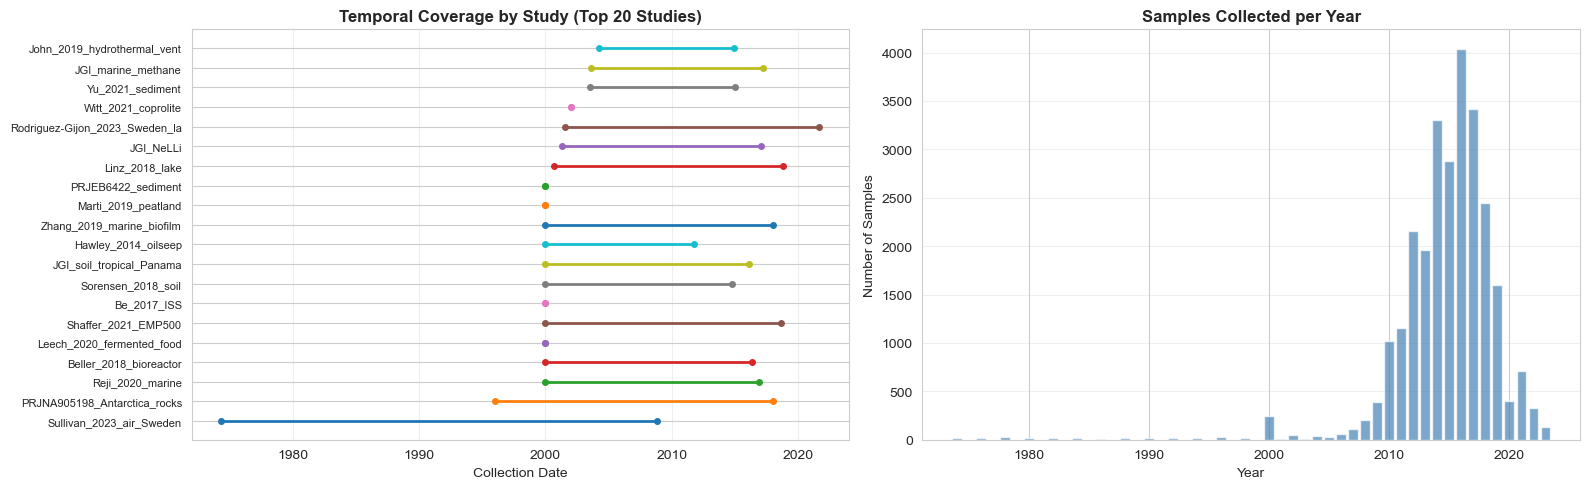

Figure saved: output/exploratory_analysis/temporal_coverage.png


In [27]:
# Visualization: Temporal coverage
if 'collection_date_parsed' in metadata_df.columns:
    valid_dates_df = metadata_df.dropna(subset=['collection_date_parsed'])
    
    if len(valid_dates_df) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        
        # Timeline
        ax1 = axes[0]
        dates_by_study = valid_dates_df.groupby('study_code')['collection_date_parsed'].agg(['min', 'max', 'count'])
        dates_by_study = dates_by_study.sort_values('min')
        
        for idx, (study, row) in enumerate(dates_by_study.head(20).iterrows()):
            ax1.plot([row['min'], row['max']], [idx, idx], 'o-', linewidth=2, markersize=4)
        
        ax1.set_yticks(range(min(20, len(dates_by_study))))
        ax1.set_yticklabels([s[:30] for s in dates_by_study.head(20).index], fontsize=8)
        ax1.set_xlabel('Collection Date')
        ax1.set_title('Temporal Coverage by Study (Top 20 Studies)', fontweight='bold')
        ax1.grid(axis='x', alpha=0.3)
        
        # Distribution over time
        ax2 = axes[1]
        valid_dates_df['year'] = valid_dates_df['collection_date_parsed'].dt.year
        samples_per_year = valid_dates_df['year'].value_counts().sort_index()
        
        ax2.bar(samples_per_year.index, samples_per_year.values, color='steelblue', alpha=0.7)
        ax2.set_xlabel('Year')
        ax2.set_ylabel('Number of Samples')
        ax2.set_title('Samples Collected per Year', fontweight='bold')
        ax2.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_PATH}/temporal_coverage.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Figure saved: {OUTPUT_PATH}/temporal_coverage.png")

---
## 7. Technical Heterogeneity

In [31]:
print("="*80)
print("TECHNICAL HETEROGENEITY ANALYSIS")
print("="*80)

# Analyze technical variables if present
technical_vars = ['filtration_lower_threshold_um', 'filtration_upper_threshold_um']
existing_tech_vars = [v for v in technical_vars if v in metadata_df.columns]

if len(existing_tech_vars) > 0:
    print(f"\nFiltration thresholds:")
    
    for var in existing_tech_vars:
        unique_values = metadata_df[var].dropna().unique()
        print(f"\n{var}:")
        print(f"  Unique values: {len(unique_values)}")
        
        if len(unique_values) <= 10:
            # Sort values, handling mixed types
            try:
                sorted_values = sorted(unique_values)
            except TypeError:
                # Mixed types - convert to string for sorting
                sorted_values = sorted([str(v) for v in unique_values])
            print(f"  Values: {sorted_values}")
        else:
            # Get numeric values only for min/max
            numeric_values = pd.to_numeric(metadata_df[var], errors='coerce').dropna()
            if len(numeric_values) > 0:
                print(f"  Range: {numeric_values.min():.2f} - {numeric_values.max():.2f}")
            else:
                # All non-numeric, show first few examples
                print(f"  Examples: {list(unique_values[:5])}")
        
        # By study
        values_per_study = metadata_df.groupby('study_code')[var].nunique()
        print(f"  Studies using multiple values: {(values_per_study > 1).sum()}")
else:
    print("\n⚠️  No technical variables (filtration) found in metadata")

# Check environment types
if 'environment_biome' in metadata_df.columns:
    print(f"\n\nEnvironment types:")
    env_counts = metadata_df['environment_biome'].value_counts()
    print(f"  Unique biomes: {len(env_counts)}")
    print(f"\n  Top 10 biomes:")
    for biome, count in env_counts.head(10).items():
        pct = count / len(metadata_df) * 100
        print(f"    {biome}: {count} ({pct:.1f}%)")

# Geographic diversity
if 'geographic_location' in metadata_df.columns:
    print(f"\n\nGeographic diversity:")
    geo_counts = metadata_df['geographic_location'].value_counts()
    print(f"  Unique locations/countries: {len(geo_counts)}")
    print(f"\n  Top 10 locations:")
    for loc, count in geo_counts.head(10).items():
        pct = count / len(metadata_df) * 100
        print(f"    {loc}: {count} ({pct:.1f}%)")

TECHNICAL HETEROGENEITY ANALYSIS

Filtration thresholds:

filtration_lower_threshold_um:
  Unique values: 10
  Values: [np.float64(0.0), np.float64(0.1), np.float64(0.2), np.float64(0.22), np.float64(0.45), np.float64(0.7), np.float64(0.8), np.float64(3.0), np.float64(5.0), np.float64(64.0)]
  Studies using multiple values: 8

filtration_upper_threshold_um:
  Unique values: 20
  Range: 0.22 - inf
  Studies using multiple values: 3


Environment types:
  Unique biomes: 129

  Top 10 biomes:
    aquatic biome [ENVO:00002030]: 2973 (11.0%)
    terrestrial biome [ENVO:00000446]: 2517 (9.3%)
    freshwater biome [ENVO:00000873]: 2135 (7.9%)
    urban biome [ENVO:01000249]: 1909 (7.1%)
    freshwater river biome [ENVO:01000253]: 1775 (6.6%)
    freshwater lake biome [ENVO:01000252]: 1374 (5.1%)
    biome [ENVO:00000428]: 1296 (4.8%)
    forest biome [ENVO:01000174]: 1296 (4.8%)
    tundra biome [ENVO:01000180]: 709 (2.6%)
    vegetated area [ENVO:01001305]: 668 (2.5%)


Geographic diversity:

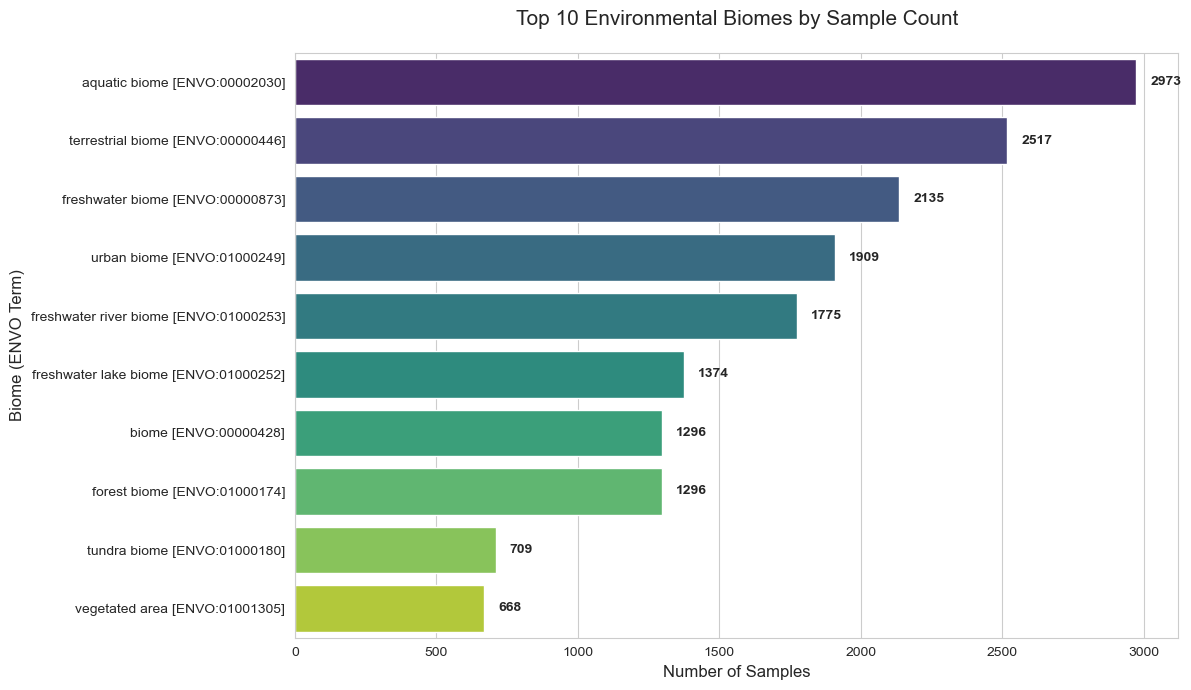

In [41]:
# Data from Heterogeneity analysis
biome_data = {
    'Biome': [
        'aquatic biome [ENVO:00002030]', 'terrestrial biome [ENVO:00000446]', 
        'freshwater biome [ENVO:00000873]', 'urban biome [ENVO:01000249]', 
        'freshwater river biome [ENVO:01000253]', 'freshwater lake biome [ENVO:01000252]', 
        'biome [ENVO:00000428]', 'forest biome [ENVO:01000174]', 
        'tundra biome [ENVO:01000180]', 'vegetated area [ENVO:01001305]'
    ],
    'Count': [2973, 2517, 2135, 1909, 1775, 1374, 1296, 1296, 709, 668]
}

df_biomes = pd.DataFrame(biome_data)

# Visualization
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Create horizontal bar plot for better readability of ENVO labels
ax = sns.barplot(x='Count', y='Biome', data=df_biomes, palette='viridis')

# Add titles and labels
plt.title('Top 10 Environmental Biomes by Sample Count', fontsize=15, pad=20)
plt.xlabel('Number of Samples', fontsize=12)
plt.ylabel('Biome (ENVO Term)', fontsize=12)

# Add value labels to the end of each bar
for i, count in enumerate(df_biomes['Count']):
    ax.text(count + 50, i, f'{count}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/top_10_biomes_by_sample_count.png', dpi=300, bbox_inches='tight')
plt.show()

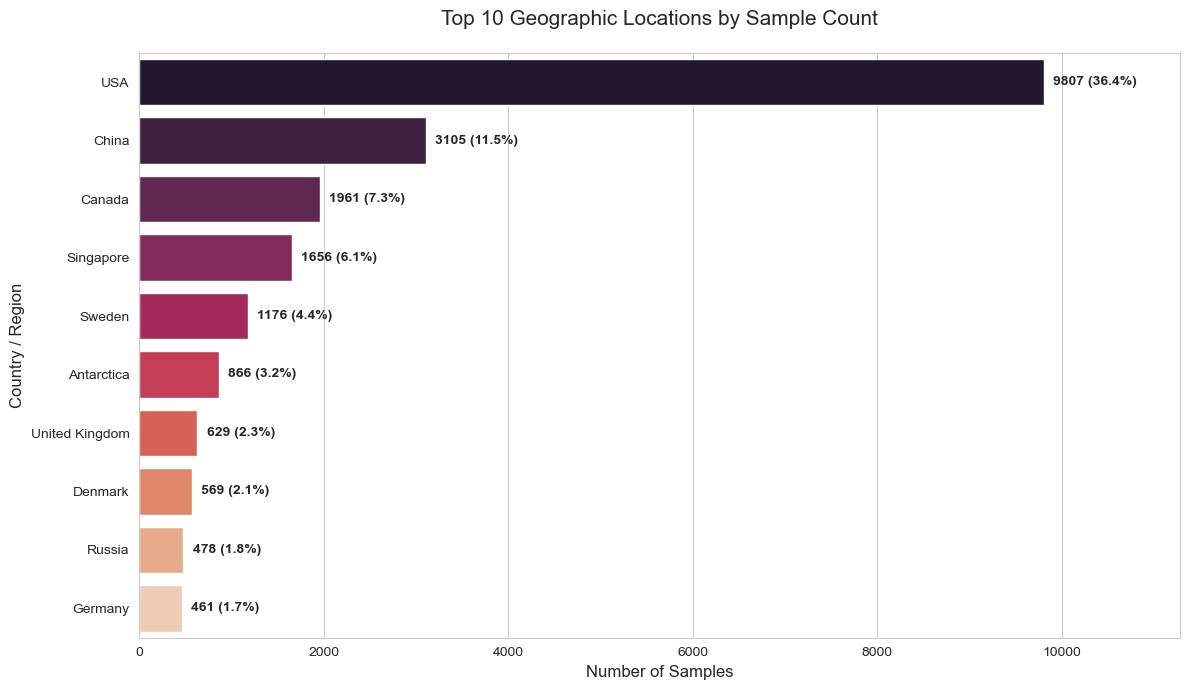

In [42]:
# Data from Geographic diversity analysis
geo_data = {
    'Location': [
        'USA', 'China', 'Canada', 'Singapore', 'Sweden', 
        'Antarctica', 'United Kingdom', 'Denmark', 'Russia', 'Germany'
    ],
    'Count': [9807, 3105, 1961, 1656, 1176, 866, 629, 569, 478, 461],
    'Percentage': [36.4, 11.5, 7.3, 6.1, 4.4, 3.2, 2.3, 2.1, 1.8, 1.7]
}

df_geo = pd.DataFrame(geo_data)

# Visualization
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Create horizontal bar plot
# Using a different color palette (rocket) to distinguish from the biome chart
ax = sns.barplot(x='Count', y='Location', data=df_geo, palette='rocket')

# Add titles and labels
plt.title('Top 10 Geographic Locations by Sample Count', fontsize=15, pad=20)
plt.xlabel('Number of Samples', fontsize=12)
plt.ylabel('Country / Region', fontsize=12)

# Add value labels and percentages to the end of each bar
for i, (count, pct) in enumerate(zip(df_geo['Count'], df_geo['Percentage'])):
    ax.text(count + 100, i, f'{count} ({pct}%)', va='center', fontsize=10, fontweight='bold')

# Adjust x-axis limit to make room for labels
plt.xlim(0, max(df_geo['Count']) * 1.15)

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/geographic_diversity.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 8. Duplicate Sample Detection

In [29]:
print("="*80)
print("DUPLICATE SAMPLE DETECTION")
print("="*80)

# Check for duplicate sample IDs
duplicate_aliases = metadata_df['sample_alias'].duplicated().sum()
print(f"\nDuplicate sample_alias values: {duplicate_aliases}")

if duplicate_aliases > 0:
    dup_samples = metadata_df[metadata_df['sample_alias'].duplicated(keep=False)]
    print(f"⚠️  Found {len(dup_samples)} rows with duplicate sample IDs")
    print("\nExamples:")
    display(dup_samples.head(10))
else:
    print("No duplicate sample IDs found")

# Check for potential duplicates based on metadata similarity
print("\n\nChecking for near-duplicate metadata profiles...")

# Select key fields for comparison
comparison_fields = ['study_code', 'longitude', 'latitude', 'collection_date', 
                    'environment_biome', 'environment_material']
existing_comparison_fields = [f for f in comparison_fields if f in metadata_df.columns]

if len(existing_comparison_fields) >= 3:
    # Group by these fields to find potential duplicates
    grouped = metadata_df.groupby(existing_comparison_fields, dropna=False).size()
    potential_duplicates = grouped[grouped > 1]
    
    print(f"  Groups with identical metadata on {len(existing_comparison_fields)} key fields: {len(potential_duplicates)}")
    
    if len(potential_duplicates) > 0:
        print(f"  Total samples in duplicate groups: {potential_duplicates.sum()}")
        print(f"\n  Largest duplicate groups:")
        for idx, count in potential_duplicates.sort_values(ascending=False).head(5).items():
            print(f"    Group: {count} samples with identical values")
        
        print("\n⚠️  These may be technical replicates, biological replicates, or true duplicates")
    else:
        print("No near-duplicate metadata profiles detected")
else:
    print("⚠️  Insufficient fields for duplicate detection")

DUPLICATE SAMPLE DETECTION

Duplicate sample_alias values: 0
No duplicate sample IDs found


Checking for near-duplicate metadata profiles...
  Groups with identical metadata on 6 key fields: 2886
  Total samples in duplicate groups: 20560

  Largest duplicate groups:
    Group: 374 samples with identical values
    Group: 359 samples with identical values
    Group: 288 samples with identical values
    Group: 282 samples with identical values
    Group: 277 samples with identical values

⚠️  These may be technical replicates, biological replicates, or true duplicates


---
## 9. Species Data Overview

In [ ]:
print("="*80)
print("SPECIES DATA OVERVIEW")
print("="*80)

print(f"\nSpecies abundance data (long format):")
print(f"  Total rows: {len(species_long):,}")
print(f"  Unique samples: {species_long['sample_alias'].nunique():,}")
print(f"  Unique species: {species_long['species'].nunique():,}")

# Calculate species per sample
species_per_sample = species_long.groupby('sample_alias').size()
print(f"\nSpecies per sample:")
print(f"  Mean: {species_per_sample.mean():.1f}")
print(f"  Median: {species_per_sample.median():.0f}")
print(f"  Min: {species_per_sample.min()}")
print(f"  Max: {species_per_sample.max()}")

# Calculate abundance statistics
print(f"\nRelative abundance statistics:")
print(f"  Mean: {species_long['rel_abund'].mean():.6f}")
print(f"  Median: {species_long['rel_abund'].median():.6f}")
print(f"  Min: {species_long['rel_abund'].min():.6f}")
print(f"  Max: {species_long['rel_abund'].max():.6f}")

# Check if abundances sum to 1 per sample
abundance_sums = species_long.groupby('sample_alias')['rel_abund'].sum()
properly_normalized = ((abundance_sums > 0.99) & (abundance_sums < 1.01)).sum()
print(f"\nNormalization check:")
print(f"  Samples where abundances sum to ~1.0: {properly_normalized} ({properly_normalized/len(abundance_sums)*100:.1f}%)")

if properly_normalized / len(abundance_sums) < 0.95:
    print("  ⚠️  Warning: Some samples may not be properly normalized")

SPECIES DATA OVERVIEW

Species abundance data (long format):
  Total rows: 1,659,836
  Unique samples: 16,994
  Unique species: 25,003

Species per sample:
  Mean: 97.7
  Median: 45
  Min: 1
  Max: 1798

Relative abundance statistics:
  Mean: 1.025041
  Median: 0.044750
  Min: 0.000000
  Max: 100.000000

Normalization check:
  Samples where abundances sum to ~1.0: 0 (0.0%)
  ⚠️  Warning: Some samples may not be properly normalized


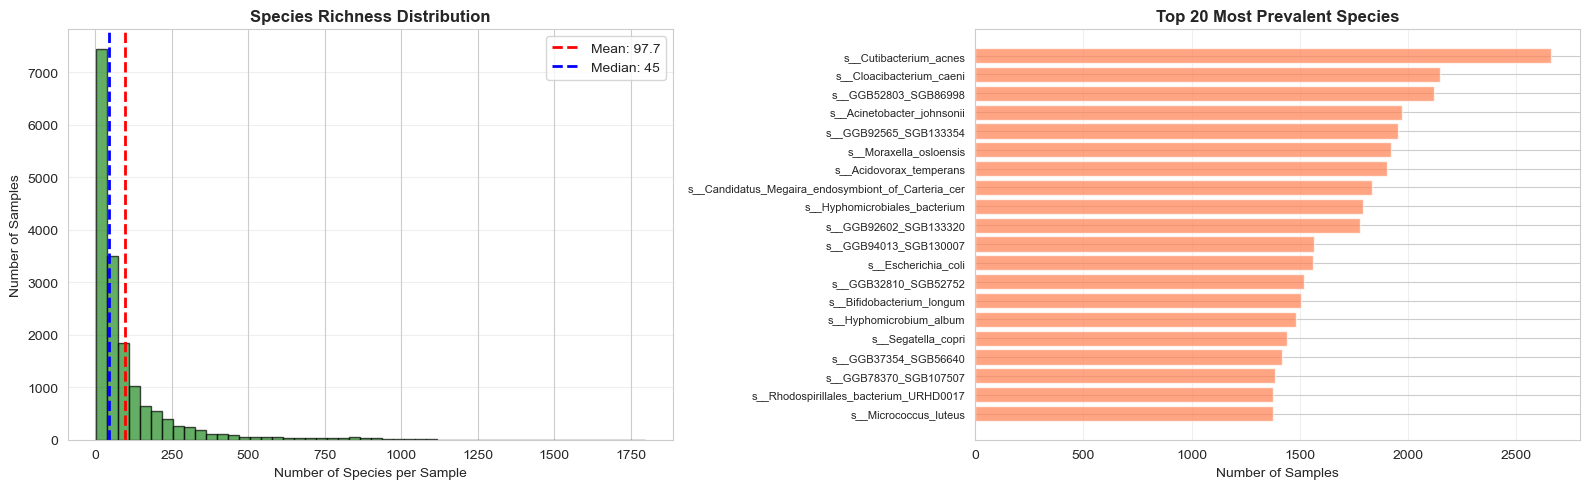

Figure saved: output/exploratory_analysis/species_overview.png


In [38]:
# Visualization: Species richness distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of species richness
ax1 = axes[0]
ax1.hist(species_per_sample, bins=50, color='forestgreen', alpha=0.7, edgecolor='black')
ax1.axvline(species_per_sample.mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {species_per_sample.mean():.1f}')
ax1.axvline(species_per_sample.median(), color='blue', linestyle='--', 
            linewidth=2, label=f'Median: {species_per_sample.median():.0f}')
ax1.set_xlabel('Number of Species per Sample')
ax1.set_ylabel('Number of Samples')
ax1.set_title('Species Richness Distribution', fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Most common species
ax2 = axes[1]
species_prevalence = species_long.groupby('species').size().sort_values(ascending=False).head(20)
ax2.barh(range(len(species_prevalence)), species_prevalence.values, color='coral', alpha=0.7)
ax2.set_yticks(range(len(species_prevalence)))
ax2.set_yticklabels([s[:50] for s in species_prevalence.index], fontsize=8)
ax2.set_xlabel('Number of Samples')
ax2.set_title('Top 20 Most Prevalent Species', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/species_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved: {OUTPUT_PATH}/species_overview.png")

---
## 10. Metadata-Species Data Integration

In [34]:
# Check for duplicates before pivoting
print("Checking for duplicate (sample_alias, species) combinations...")

# Identify duplicates
duplicates = species_long[species_long.duplicated(subset=['sample_alias', 'species'], keep=False)]

if len(duplicates) > 0:
    print(f"\n⚠️  Found {len(duplicates)} rows with duplicate (sample_alias, species) pairs")
    print(f"  Affecting {duplicates.groupby(['sample_alias', 'species']).size().reset_index(name='count').shape[0]} unique combinations\n")
    
    # Show examples
    print("Examples of duplicates:")
    dup_examples = duplicates.groupby(['sample_alias', 'species']).size().reset_index(name='count')
    print(dup_examples[dup_examples['count'] > 1].head(10))
    
    print("\n\nHandling duplicates by aggregating (summing) relative abundances...")
    species_long_agg = species_long.groupby(['sample_alias', 'species'], as_index=False)['rel_abund'].sum()
    print(f"Aggregated from {len(species_long)} to {len(species_long_agg)} rows")
    species_long = species_long_agg
else:
    print("No duplicate (sample_alias, species) pairs found")

print("\nCreating wide-format abundance matrix...")
abundance_wide = species_long.pivot(index='sample_alias', 
                                     columns='species', 
                                     values='rel_abund').fillna(0)

print(f"Wide matrix created: {abundance_wide.shape[0]} samples × {abundance_wide.shape[1]} species")

# Save for downstream analyses
abundance_wide.to_csv(f'{OUTPUT_PATH}/abundance_matrix_wide.csv')
print(f"Saved: {OUTPUT_PATH}/abundance_matrix_wide.csv")

Checking for duplicate (sample_alias, species) combinations...

⚠️  Found 12792 rows with duplicate (sample_alias, species) pairs
  Affecting 6396 unique combinations

Examples of duplicates:
                sample_alias  \
0  JGI_marine_SAO_DOC.185594   
1  JGI_marine_SAO_DOC.185594   
2  JGI_marine_SAO_DOC.185594   
3  JGI_marine_SAO_DOC.185594   
4  JGI_marine_SAO_DOC.185594   
5  JGI_marine_SAO_DOC.185594   
6  JGI_marine_SAO_DOC.185594   
7  JGI_marine_SAO_DOC.185594   
8  JGI_marine_SAO_DOC.185594   
9  JGI_marine_SAO_DOC.185594   

                                             species  count  
0       s__Alphaproteobacteria_unclassified_SGB51059      2  
1       s__Alphaproteobacteria_unclassified_SGB68887      2  
2                            s__Alteromonas_gracilis      2  
3                           s__Alteromonas_macleodii      2  
4                        s__Alteromonas_mediterranea      2  
5         s__Bacteroidetes_bacterium_SCGC_AAA795_G10      2  
6              s__Bac

---
## 11.1. Correlation Analysis: Numeric Metadata

Analyzing correlations for 5 numeric variables...


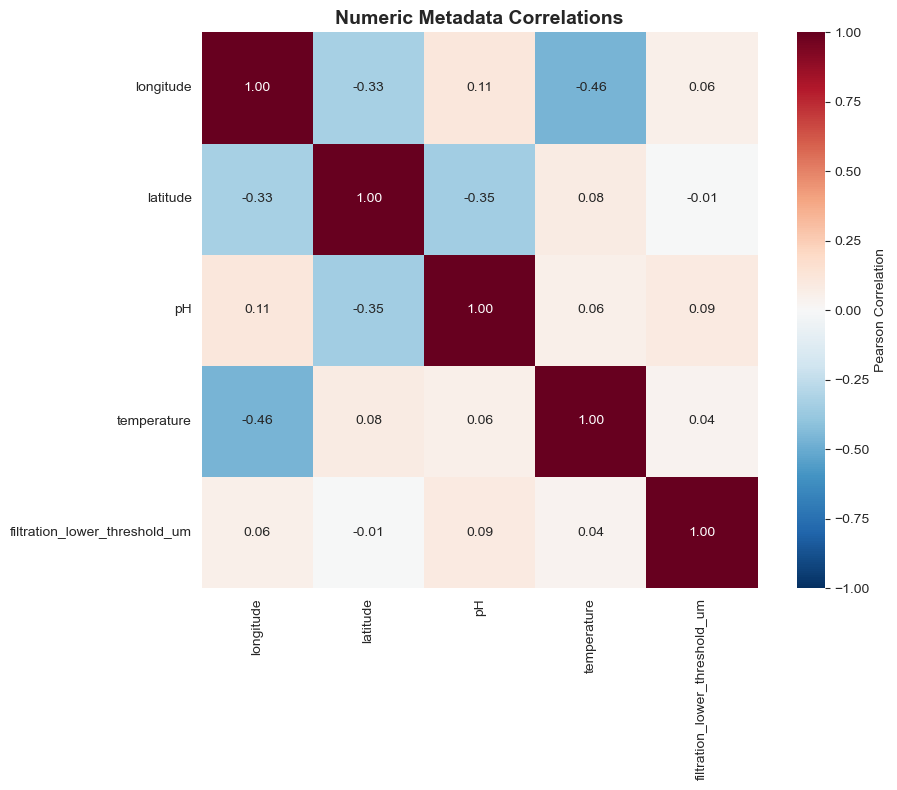

Figure saved: output/exploratory_analysis/metadata_correlations.png


In [35]:
# Analyze correlations between numeric metadata variables
numeric_cols = metadata_df.select_dtypes(include=[np.number]).columns.tolist()

# Remove identifiers and codes
exclude_keywords = ['id', 'code', 'tax']
numeric_cols = [c for c in numeric_cols if not any(kw in c.lower() for kw in exclude_keywords)]

if len(numeric_cols) >= 2:
    print(f"Analyzing correlations for {len(numeric_cols)} numeric variables...")
    
    # Calculate correlation matrix
    corr_matrix = metadata_df[numeric_cols].corr()
    
    # Visualize
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', 
                center=0, vmin=-1, vmax=1, square=True,
                cbar_kws={'label': 'Pearson Correlation'})
    plt.title('Numeric Metadata Correlations', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_PATH}/metadata_correlations.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Figure saved: {OUTPUT_PATH}/metadata_correlations.png")
    
    # Identify high correlations
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.7:
                high_corr_pairs.append({
                    'Var1': corr_matrix.columns[i],
                    'Var2': corr_matrix.columns[j],
                    'Correlation': corr_val
                })
    
    if len(high_corr_pairs) > 0:
        print("\n⚠️  High correlations detected (|r| > 0.7):")
        for pair in high_corr_pairs:
            print(f"  {pair['Var1']} <-> {pair['Var2']}: r = {pair['Correlation']:.3f}")
else:
    print("⚠️  Insufficient numeric variables for correlation analysis")

---
## 11.2. Correlation Analysis: Categorical Metadata

CATEGORICAL VARIABLE ASSOCIATIONS

Identified 5 categorical variables for analysis:
  - location_resolution (7 categories)
  - environmental_package (8 categories)
  - artificial (6 categories)
  - filtration_lower_threshold_um (10 categories)
  - filtration_upper_threshold_um (20 categories)


Analyzed 10 variable pairs

🔍 Strong associations found (Cramér's V > 0.5):

Cramér's V interpretation:
  0.0-0.1: Negligible association
  0.1-0.3: Weak association
  0.3-0.5: Moderate association
  0.5-0.7: Strong association
  0.7-1.0: Very strong association

  artificial <-> filtration_upper_threshold_um
    Cramér's V = 0.640, p = 0.0000 ***
    N = 564 samples
  artificial <-> filtration_lower_threshold_um
    Cramér's V = 0.632, p = 0.0000 ***
    N = 580 samples

⚠️  RECOMMENDATION - Potentially redundant categorical variables:


Moderate associations (0.3 < V ≤ 0.5): 6 pairs
  environmental_package <-> filtration_lower_threshold_um: V = 0.388
  location_resolution <-> filtration_lower_

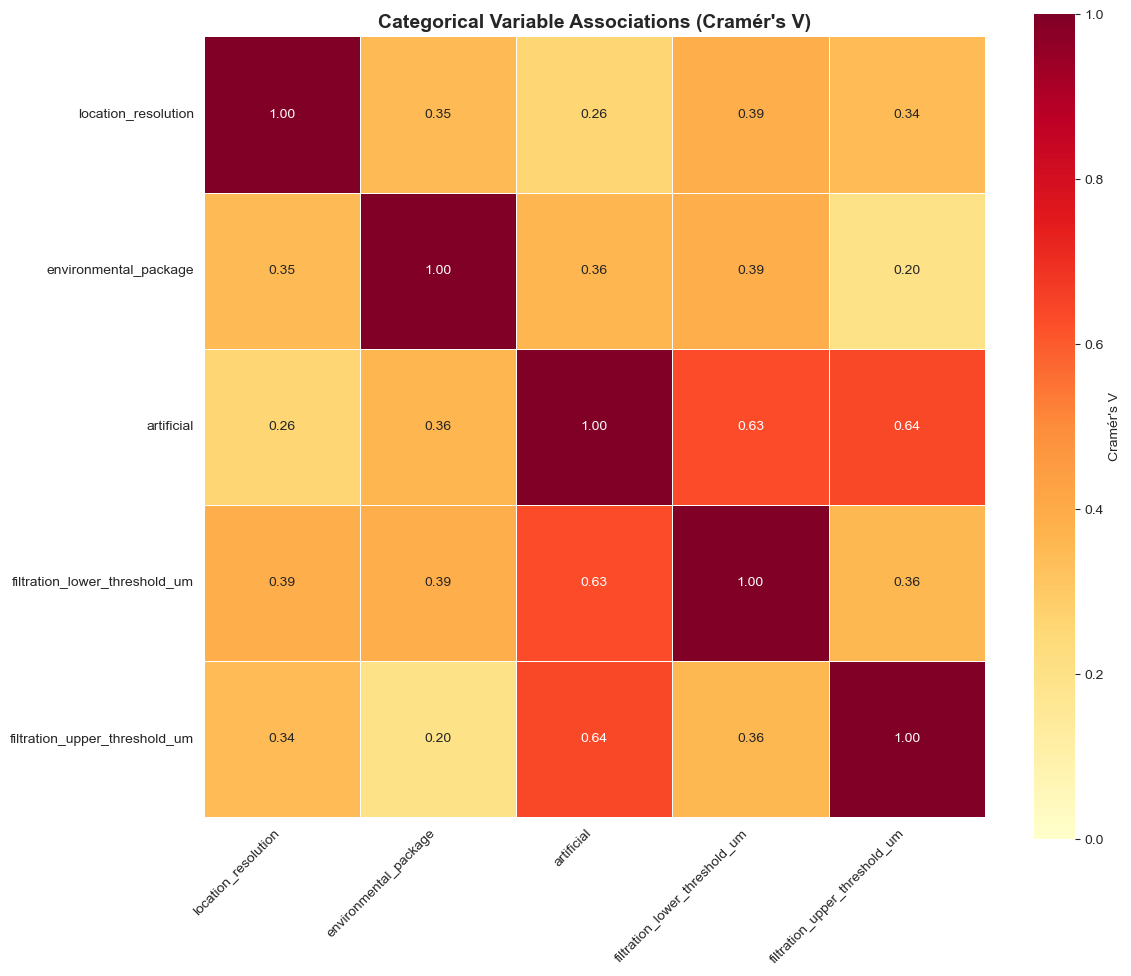

✓ Figure saved: output/categorical_associations_heatmap.png
✓ Association table saved: output/categorical_associations.csv


In [ ]:
# Analyze associations between categorical variables using Chi-square test
print("="*80)
print("CATEGORICAL VARIABLE ASSOCIATIONS")
print("="*80)

# Identify categorical variables
categorical_cols = []
for col in metadata_df.columns:
    # Skip identifiers and columns with too many unique values
    if col in ['sample_alias', 'spire_sample_name', 'study_code']:
        continue
    
    # Check if non-numeric or has few unique values
    if not pd.api.types.is_numeric_dtype(metadata_df[col]):
        unique_count = metadata_df[col].nunique()
        # Only include if has reasonable number of categories (2-50)
        if 2 <= unique_count <= 50:
            categorical_cols.append(col)
    else:
        # Numeric but with few unique values might be categorical
        unique_count = metadata_df[col].nunique()
        if 2 <= unique_count <= 10:
            categorical_cols.append(col)

print(f"\nIdentified {len(categorical_cols)} categorical variables for analysis:")
for col in categorical_cols:
    n_cat = metadata_df[col].nunique()
    print(f"  - {col} ({n_cat} categories)")

if len(categorical_cols) >= 2:
    # Calculate Cramér's V for all pairs
    from scipy.stats import chi2_contingency
    
    associations = []
    
    for i in range(len(categorical_cols)):
        for j in range(i+1, len(categorical_cols)):
            var1 = categorical_cols[i]
            var2 = categorical_cols[j]
            
            # Create contingency table (remove NaN)
            data_subset = metadata_df[[var1, var2]].dropna()
            
            if len(data_subset) < 10:
                continue  # Skip if too few samples
            
            contingency = pd.crosstab(data_subset[var1], data_subset[var2])
            
            # Chi-square test
            try:
                chi2, p_value, dof, expected = chi2_contingency(contingency)
                
                # Cramér's V (effect size for chi-square)
                # V = sqrt(chi2 / (n * min(r-1, c-1)))
                n = contingency.sum().sum()
                min_dim = min(contingency.shape[0] - 1, contingency.shape[1] - 1)
                
                if min_dim > 0:
                    cramers_v = np.sqrt(chi2 / (n * min_dim))
                    
                    associations.append({
                        'Variable1': var1,
                        'Variable2': var2,
                        'Cramers_V': cramers_v,
                        'Chi2': chi2,
                        'P_value': p_value,
                        'N_samples': n,
                        'Significant': p_value < 0.05
                    })
            except Exception as e:
                # Skip if test fails (e.g., empty cells, constant values)
                continue
    
    if len(associations) > 0:
        assoc_df = pd.DataFrame(associations).sort_values('Cramers_V', ascending=False)
        
        print(f"\n\nAnalyzed {len(associations)} variable pairs")
        
        # Show strong associations
        strong_assoc = assoc_df[assoc_df['Cramers_V'] > 0.5]
        
        if len(strong_assoc) > 0:
            print(f"\n🔍 Strong associations found (Cramér's V > 0.5):")
            print("\nCramér's V interpretation:")
            print("  0.0-0.1: Negligible association")
            print("  0.1-0.3: Weak association")
            print("  0.3-0.5: Moderate association")
            print("  0.5-0.7: Strong association")
            print("  0.7-1.0: Very strong association\n")
            
            for _, row in strong_assoc.iterrows():
                sig_marker = " ***" if row['P_value'] < 0.001 else " **" if row['P_value'] < 0.01 else " *" if row['P_value'] < 0.05 else ""
                print(f"  {row['Variable1']} <-> {row['Variable2']}")
                print(f"    Cramér's V = {row['Cramers_V']:.3f}, p = {row['P_value']:.4f}{sig_marker}")
                print(f"    N = {row['N_samples']} samples")
            
            print("\n⚠️  RECOMMENDATION - Potentially redundant categorical variables:")
            for _, row in strong_assoc[strong_assoc['Cramers_V'] > 0.7].iterrows():
                print(f"   - {row['Variable1']} and {row['Variable2']} (V={row['Cramers_V']:.3f})")
                print(f"     → Consider keeping only one for downstream analysis")
        else:
            print("\n✓ No strong associations (V > 0.5) found between categorical variables")
        
        # Show moderate associations
        moderate_assoc = assoc_df[(assoc_df['Cramers_V'] >= 0.3) & (assoc_df['Cramers_V'] <= 0.5)]
        if len(moderate_assoc) > 0:
            print(f"\n\nModerate associations (0.3 < V ≤ 0.5): {len(moderate_assoc)} pairs")
            for _, row in moderate_assoc.head(10).iterrows():
                print(f"  {row['Variable1']} <-> {row['Variable2']}: V = {row['Cramers_V']:.3f}")
        
        # Create Cramér's V heatmap
        if len(categorical_cols) <= 20:  # Only create heatmap if manageable size
            print(f"\n\nCreating Cramér's V heatmap...")
            
            # Create matrix
            cramers_matrix = pd.DataFrame(
                np.zeros((len(categorical_cols), len(categorical_cols))),
                index=categorical_cols,
                columns=categorical_cols
            )
            
            # Fill matrix
            for _, row in assoc_df.iterrows():
                cramers_matrix.loc[row['Variable1'], row['Variable2']] = row['Cramers_V']
                cramers_matrix.loc[row['Variable2'], row['Variable1']] = row['Cramers_V']
            
            # Set diagonal to 1
            np.fill_diagonal(cramers_matrix.values, 1.0)
            
            # Plot
            plt.figure(figsize=(12, 10))
            sns.heatmap(cramers_matrix, annot=True, fmt='.2f', cmap='YlOrRd', 
                        vmin=0, vmax=1, square=True, linewidths=0.5,
                        cbar_kws={'label': "Cramér's V"})
            plt.title("Categorical Variable Associations (Cramér's V)", 
                     fontweight='bold', fontsize=14)
            plt.xticks(rotation=45, ha='right')
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.savefig(f'{OUTPUT_PATH}/categorical_associations_heatmap.png', dpi=300, bbox_inches='tight')
            plt.show()
            
            print(f"Figure saved: {OUTPUT_PATH}/categorical_associations_heatmap.png")
        else:
            print(f"\n⚠️  Too many categorical variables ({len(categorical_cols)}) for heatmap visualization")
        
        # Save association table
        assoc_df.to_csv(f'{OUTPUT_PATH}/categorical_associations.csv', index=False)
        print("Association table saved: output/categorical_associations.csv")
        
    else:
        print("\n⚠️  No valid associations could be calculated")
        print("   Possible reasons:")
        print("   - Too few samples with complete data")
        print("   - Variables are constant within analyzed subset")
        print("   - All contingency tables have empty cells")
        
else:
    print("\n⚠️  Need at least 2 categorical variables for association analysis")

---
## 12. Conclusions and Recommendations

In [ ]:
print("="*80)
print("CONCLUSIONS AND RECOMMENDATIONS")
print("="*80)

# Dataset balance
print("\n1. DATASET BALANCE")
print("-"*80)

# Calculate Gini coefficient for study balance
def gini_coefficient(x):
    """Calculate Gini coefficient (0=perfect equality, 1=perfect inequality)."""
    sorted_x = np.sort(x)
    n = len(x)
    cumsum = np.cumsum(sorted_x)
    return (2 * np.sum((n - np.arange(1, n+1) + 0.5) * sorted_x)) / (n * np.sum(sorted_x)) - 1

gini = gini_coefficient(samples_per_study.values)

print(f"\nGini coefficient for study distribution: {gini:.3f}")
if gini < 0.3:
    print("Dataset is relatively balanced across studies")
elif gini < 0.6:
    print("  ⚠️  Dataset shows moderate imbalance (some large studies dominate)")
else:
    print("  ⚠️  Dataset is highly imbalanced (dominated by few large studies)")

top_10_pct = samples_per_study.nlargest(10).sum() / total_samples_meta * 100
print(f"\nTop 10 studies represent {top_10_pct:.1f}% of total samples")

# Missing data patterns
print("\n\n2. MISSING DATA PATTERNS")
print("-"*80)

critical_missing = missing_summary[missing_summary['Missing_Percent'] > 50]
if len(critical_missing) > 0:
    print(f"\n⚠️  {len(critical_missing)} variables have >50% missing data")
    print("  These variables may introduce bias if used without careful handling")
    print("\n  Recommended actions:")
    print("  - Exclude variables with >90% missing from analyses")
    print("  - For variables with 50-90% missing, consider:")
    print("    • Subset analyses (only studies with complete data)")
    print("    • Imputation (if missing at random)")
    print("    • Binary indicators (present/absent)")
else:
    print("✓ No systematic missing data issues detected")

# Duplicate handling
print("\n\n3. DUPLICATE SAMPLE HANDLING")
print("-"*80)

if duplicate_aliases > 0:
    print(f"\n⚠️  {duplicate_aliases} duplicate sample IDs detected")
    print("\n  Recommended actions:")
    print("  - Investigate whether these are:")
    print("    • Technical replicates (average or keep one)")
    print("    • Biological replicates (keep separate)")
    print("    • Data entry errors (correct)")
    print("  - Remove exact duplicates before analysis")
else:
    print("No duplicate sample IDs found")

if len(longitudinal_bases) > 0:
    print(f"\n  {len(longitudinal_bases)} potential longitudinal series detected")
    print("  - Account for repeated measures in statistical analyses")
    print("  - Use mixed-effects models or GEE when appropriate")

# Overall suitability
print("\n\n4. OVERALL DATASET SUITABILITY")
print("-"*80)

print("\nStrengths:")
print(f"  + Large sample size ({total_samples_meta:,} samples)")
print(f"  + Multiple independent studies ({n_studies} studies)")
print(f"  + Rich species diversity ({species_long['species'].nunique():,} unique species)")

print("\nConsiderations for downstream analysis:")
if gini > 0.5:
    print("  • Account for study imbalance in statistical models")
if len(critical_missing) > 0:
    print("  • Handle missing data appropriately")
if len(longitudinal_bases) > 0:
    print("  • Account for repeated measures")
print("  • Consider batch effects between studies")
print("  • Validate findings across multiple studies when possible")

CONCLUSIONS AND RECOMMENDATIONS

1. DATASET BALANCE
--------------------------------------------------------------------------------

Gini coefficient for study distribution: -0.639
  ✓ Dataset is relatively balanced across studies

Top 10 studies represent 25.8% of total samples


2. MISSING DATA PATTERNS
--------------------------------------------------------------------------------

⚠️  10 variables have >50% missing data
  These variables may introduce bias if used without careful handling

  Recommended actions:
  - Exclude variables with >90% missing from analyses
  - For variables with 50-90% missing, consider:
    • Subset analyses (only studies with complete data)
    • Imputation (if missing at random)
    • Binary indicators (present/absent)


3. DUPLICATE SAMPLE HANDLING
--------------------------------------------------------------------------------
✓ No duplicate sample IDs found

  64 potential longitudinal series detected
  - Account for repeated measures in statistica

In [ ]:
with open('output/exploratory_analysis_summary.txt', 'w') as f:
    f.write("="*80 + "\n")
    f.write("EXPLORATORY ANALYSIS SUMMARY REPORT\n")
    f.write("="*80 + "\n\n")
    
    f.write("DATASET OVERVIEW\n")
    f.write("-"*80 + "\n")
    f.write(f"Total samples: {total_samples_meta:,}\n")
    f.write(f"Number of studies: {n_studies}\n")
    f.write(f"Unique species detected: {species_long['species'].nunique():,}\n")
    f.write(f"Metadata variables: {len(metadata_df.columns)}\n")
    
    f.write("\n\nSTUDY DISTRIBUTION\n")
    f.write("-"*80 + "\n")
    f.write(f"Min samples per study: {samples_per_study.min()}\n")
    f.write(f"Max samples per study: {samples_per_study.max()}\n")
    f.write(f"Mean samples per study: {samples_per_study.mean():.1f}\n")
    f.write(f"Median samples per study: {samples_per_study.median():.0f}\n")
    f.write(f"Gini coefficient: {gini:.3f}\n")
    
    f.write("\n\nMISSING DATA\n")
    f.write("-"*80 + "\n")
    f.write(f"Variables with >50% missing: {len(critical_missing)}\n")
    f.write(f"Variables with no missing data: {(missing_summary['Missing_Percent'] == 0).sum()}\n")
    
    f.write("\n\nQUALITY METRICS\n")
    f.write("-"*80 + "\n")
    f.write(f"Duplicate sample IDs: {duplicate_aliases}\n")
    f.write(f"Potential longitudinal series: {len(longitudinal_bases)}\n")
    f.write(f"Mean species per sample: {species_per_sample.mean():.1f}\n")

print(f"\nSummary report saved: {OUTPUT_PATH}/exploratory_analysis_summary.txt")


Summary report saved: output/exploratory_analysis/exploratory_analysis_summary.txt


---
## Analysis Complete

**Outputs Generated:**
1. `study_distribution.png` - Study sample count visualizations
2. `missing_data_summary.csv` - Complete missing data report
3. `missing_data_heatmap.png` - Visual missing data patterns
4. `temporal_coverage.png` - Timeline and temporal distribution
5. `species_overview.png` - Species richness and prevalence
6. `abundance_matrix_wide.csv` - Wide-format abundance matrix
7. `metadata_correlations.png` - Numeric variable correlations
8. `exploratory_analysis_summary.txt` - Comprehensive text report

**Next Steps:**
- Review identified issues (duplicates, missing data, imbalance)
- Decide on data preprocessing strategy
- Plan downstream analyses accounting for study heterogeneity
- Consider subset analyses if needed